# Task 4 · Llama-3 Zero-shot & Few-shot Classification

**NALAPRO project · 20 Newsgroups · Master's NLP**

This notebook handles **Task 4 only**: prompting Llama-3-8B-Instruct on the
20-Newsgroups classification task in zero-shot and few-shot regimes. **No
training happens here.** The bonus task (QLoRA fine-tuning) lives in a
separate notebook so the two can be run in different Colab sessions and
don't fight over GPU memory.

## What this notebook produces

1. **Zero-shot evaluation** of Llama-3-8B-Instruct on a balanced 300-doc
   test set (15 per class × 20 classes).
2. **Few-shot evaluation** at k = 1, 3, 5 demonstrations.
3. **All metrics + confusion matrices** logged to Weights & Biases.
4. **`task4_metrics.json`** saved to disk — the bonus notebook reads it for
   the side-by-side comparison.

## Wall-clock estimate (T4 GPU)

| Stage | Time |
|---|---|
| Setup + data + model load | ~10 min |
| Zero-shot eval | ~6 min |
| Few-shot k=1 / 3 / 5 | ~6 / ~10 / ~15 min |
| **Total** | **~50 min** |

## Tools used (rubric §5.b/c disclosure)

- `transformers`, `peft`, `bitsandbytes` — model loading + 4-bit quantization
- `scikit-learn` — `fetch_20newsgroups`, metrics
- `wandb` — experiment tracking (required by rubric)
- `matplotlib`, `seaborn` — plots
- AI assistance (Anthropic Claude) — used for boilerplate and debugging.
  All modeling choices defended below; every cell is annotated.

## 1 · Install

Pinned to known-working versions. Skip this cell if your runtime already
has them installed (look at the imports cell — if it imports cleanly, the
versions you have are fine).

In [1]:
%%capture
!pip install -q -U bitsandbytes>=0.43
!pip install -q -U "transformers>=4.40,<4.46"
!pip install -q -U accelerate>=0.30
!pip install -q -U "peft>=0.10,<0.13"
!pip install -q -U wandb>=0.17
!pip install -q -U scikit-learn matplotlib seaborn

## 2 · Imports, seed, GPU check

We want this notebook to refuse to run if there's no GPU — Llama-3-8B
inference on CPU would take all night.

In [2]:
import os, json, random, gc, warnings
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    BitsAndBytesConfig, pipeline,
    logging as hf_logging,
)
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

os.environ["TOKENIZERS_PARALLELISM"] = "false"
hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), \
    "This notebook needs a GPU. Runtime → Change runtime type → T4 GPU."

print("Device :", torch.cuda.get_device_name(0))
print("VRAM   :", f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("Free   :", f"{torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

Device : Tesla T4
VRAM   : 15.6 GB
Free   : 15.5 GB


## 3 · Experiment configuration

All knobs in one place. The defaults below are calibrated for a single T4
— big enough to be a meaningful evaluation, small enough to finish in well
under an hour.

In [3]:
# Data sizes — balanced subsample
N_TEST_PER_CLASS  = 15      # 15 × 20 = 300 test docs
N_TRAIN_PER_CLASS = 50      # 50 × 20 = 1 000 train docs (used as demo source)
MAX_DOC_CHARS     = 500     # truncate posts (≈ 120 tokens) — keeps prompts tight

# Few-shot sweep
FEW_SHOT_KS = [1, 3, 5]

# Model + W&B
BASE_MODEL     = "meta-llama/Meta-Llama-3-8B-Instruct"
WANDB_PROJECT  = "nalapro-task4-llama3"

# Where to dump metrics for the bonus notebook to pick up
METRICS_OUTPUT = Path("task4_metrics.json")

print(f"Train docs (demo source): {N_TRAIN_PER_CLASS * 20}")
print(f"Test docs:                {N_TEST_PER_CLASS  * 20}")

Train docs (demo source): 1000
Test docs:                300


## 4 · Hugging Face & Weights & Biases login

Both tokens must be set as Colab/Kaggle Secrets named exactly `HF_TOKEN` and
`WANDB_API_KEY`. The HF token needs the **'Read public gated repos'**
permission for Llama-3 — see `https://huggingface.co/settings/tokens`.

In [4]:
from huggingface_hub import login as hf_login

def _get_secret(name):
    v = os.environ.get(name)
    if v: return v
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(name)
    except Exception:
        pass
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return None

hf_tok = _get_secret("HF_TOKEN")
assert hf_tok, "HF_TOKEN not set. Add it as a Colab/Kaggle secret."
hf_login(token=hf_tok)
print("HF login OK")

wb_tok = _get_secret("WANDB_API_KEY")
assert wb_tok, "WANDB_API_KEY not set. Get one at https://wandb.ai/authorize"
wandb.login(key=wb_tok)
print("W&B login OK")

HF login OK


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: likhita-kolli (likhita-kolli-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login OK


## 5 · Load 20 Newsgroups

We strip headers, footers, and quoted replies — the raw headers literally
name the newsgroup, which would invalidate every evaluation downstream.

In [5]:
train_bunch = fetch_20newsgroups(subset="train",
                                 remove=("headers", "footers", "quotes"),
                                 shuffle=True, random_state=SEED)
test_bunch  = fetch_20newsgroups(subset="test",
                                 remove=("headers", "footers", "quotes"),
                                 shuffle=True, random_state=SEED)

LABELS      = list(train_bunch.target_names)
NUM_CLASSES = len(LABELS)
LABEL2ID    = {l: i for i, l in enumerate(LABELS)}
ID2LABEL    = {i: l for i, l in enumerate(LABELS)}

print(f"Loaded {len(train_bunch.data)} train / {len(test_bunch.data)} test docs across {NUM_CLASSES} classes")

Loaded 11314 train / 7532 test docs across 20 classes


### 5.1 Balanced subsample

Take exactly `N_PER_CLASS` non-empty docs from each class, truncate to
`MAX_DOC_CHARS`. Balanced sampling makes macro-F1 a meaningful comparison.

In [6]:
def subsample_balanced(texts, labels, n_per_class):
    kept_t, kept_y = [], []
    cnt = {i: 0 for i in range(NUM_CLASSES)}
    for t, y in zip(texts, labels):
        if not t or not t.strip():
            continue
        if cnt[int(y)] < n_per_class:
            kept_t.append(t.strip()[:MAX_DOC_CHARS])
            kept_y.append(int(y))
            cnt[int(y)] += 1
        if all(c >= n_per_class for c in cnt.values()):
            break
    return kept_t, np.asarray(kept_y)

train_texts, train_labels = subsample_balanced(
    train_bunch.data, train_bunch.target, N_TRAIN_PER_CLASS
)
test_texts,  test_labels  = subsample_balanced(
    test_bunch.data, test_bunch.target, N_TEST_PER_CLASS
)

print(f"Final: {len(train_texts)} train (demo source), {len(test_texts)} test")

Final: 1000 train (demo source), 300 test


## 6 · Prompt templates

Two prompts to define: zero-shot and few-shot.

The instruction lists all 20 categories explicitly. Without this the model
invents labels like `'computer graphics'` instead of `comp.graphics`.

In [7]:
CATEGORY_BLOCK = "\n".join(f"  {i}. {lbl}" for i, lbl in enumerate(LABELS))
INSTRUCTION = (
    "Classify the following newsgroup post into exactly one of the 20 "
    "categories below. Respond with only the category name (e.g. "
    "`rec.sport.hockey`) and nothing else.\n\n"
    f"Categories:\n{CATEGORY_BLOCK}"
)

def build_zero_shot_prompt(text: str) -> str:
    return f"{INSTRUCTION}\n\nPost:\n{text}\n\nlabel:"

def build_few_shot_prompt(text: str, demos: List[Tuple[str, str]]) -> str:
    parts = [INSTRUCTION, ""]
    for d_text, d_label in demos:
        parts.append(f"Post:\n{d_text}\n\nlabel: {d_label}")
        parts.append("")
    parts.append(f"Post:\n{text}\n\nlabel:")
    return "\n".join(parts)

print("--- Example zero-shot prompt -------------------------------------")
print(build_zero_shot_prompt(test_texts[0])[:600], "  ...[truncated]")

--- Example zero-shot prompt -------------------------------------
Classify the following newsgroup post into exactly one of the 20 categories below. Respond with only the category name (e.g. `rec.sport.hockey`) and nothing else.

Categories:
  0. alt.atheism
  1. comp.graphics
  2. comp.os.ms-windows.misc
  3. comp.sys.ibm.pc.hardware
  4. comp.sys.mac.hardware
  5. comp.windows.x
  6. misc.forsale
  7. rec.autos
  8. rec.motorcycles
  9. rec.sport.baseball
  10. rec.sport.hockey
  11. sci.crypt
  12. sci.electronics
  13. sci.med
  14. sci.space
  15. soc.religion.christian
  16. talk.politics.guns
  17. talk.politics.mideast
  18. talk.politics.misc
  19.    ...[truncated]


## 7 · Load Llama-3-8B-Instruct in 4-bit (bf16 compute)

All the lessons from tonight's debugging baked in:

1. **`bnb_4bit_compute_dtype=torch.bfloat16`** — bf16 avoids the fp16 grad-
   scaler incompatibility that breaks training (matters for the bonus, but
   we use the same dtype here for consistency).
2. **`bnb_4bit_use_double_quant=True`** — saves ~1 GB by quantizing the
   quantization constants themselves. Standard QLoRA recipe.
3. **`device_map={"": 0}`** — force every layer to GPU 0. `"auto"` will
   silently offload to CPU when memory looks tight and then training will
   fail with a confusing error.
4. **`torch_dtype=torch.bfloat16`** — matches the bnb compute dtype.

If this cell OOMs, see the troubleshooting cell at the very end.

In [8]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("Loading Llama-3-8B-Instruct (~5 min on first download)...")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.bfloat16,
)
model.config.use_cache = True     # ON for inference (faster generation)
model.config.pretraining_tp = 1

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "right"

print("Model + tokenizer ready.")
print(f"VRAM in use: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

Loading Llama-3-8B-Instruct (~5 min on first download)...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Model + tokenizer ready.
VRAM in use: 5.7 GB


## 8 · Evaluation helpers

Three functions: `predict`, `evaluate`, `log_to_wandb`. They are reused for
every regime so the comparison is apples-to-apples.

Decoding is **greedy** (`do_sample=False`) — classification needs
determinism, not creativity. `max_new_tokens=8` is enough for the longest
label (`talk.politics.mideast`).

In [9]:
def make_pipeline():
    return pipeline(
        task="text-generation",
        model=model, tokenizer=tokenizer,
        max_new_tokens=8,
        do_sample=False,
        return_full_text=False,
        pad_token_id=tokenizer.eos_token_id,
    )

def parse_label(generated: str) -> str:
    """Longest-match-first substring search — picks rec.sport.hockey
    over rec.sport, never the other way around."""
    text = generated.strip().lower()
    for lbl in sorted(LABELS, key=len, reverse=True):
        if lbl.lower() in text:
            return lbl
    return "unknown"

def predict(prompts, pipe):
    preds = []
    for p in tqdm(prompts, desc="predicting"):
        out = pipe(p)
        preds.append(parse_label(out[0]["generated_text"]))
    return preds

def evaluate(y_true, y_pred, name: str) -> Dict:
    yt = np.array([LABEL2ID[l]            for l in y_true])
    yp = np.array([LABEL2ID.get(l, -1)    for l in y_pred])
    acc       = accuracy_score(yt, yp)
    f1_macro  = f1_score(yt, yp, average="macro",
                         labels=list(range(NUM_CLASSES)), zero_division=0)
    f1_weight = f1_score(yt, yp, average="weighted",
                         labels=list(range(NUM_CLASSES)), zero_division=0)
    cm = confusion_matrix(yt, yp, labels=list(range(NUM_CLASSES)))
    print(f"\n=== {name} ===  acc={acc:.4f}  macro-F1={f1_macro:.4f}  weighted-F1={f1_weight:.4f}")
    print(classification_report(yt, yp, labels=list(range(NUM_CLASSES)),
                                target_names=LABELS, zero_division=0))
    return dict(run_name=name, accuracy=acc, f1_macro=f1_macro,
                f1_weighted=f1_weight, cm=cm.tolist())

def plot_cm(cm, name):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(np.array(cm), xticklabels=LABELS, yticklabels=LABELS,
                cmap="Blues", annot=False, ax=ax)
    ax.set_title(f"Confusion matrix — {name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.xticks(rotation=90); plt.yticks(rotation=0)
    plt.tight_layout()
    return fig

def log_to_wandb(metrics: Dict, name: str, extra=None):
    run = wandb.init(project=WANDB_PROJECT, name=name, reinit=True,
                     config={"seed": SEED, **(extra or {})})
    run.log({
        "accuracy":    metrics["accuracy"],
        "f1_macro":    metrics["f1_macro"],
        "f1_weighted": metrics["f1_weighted"],
        "confusion_matrix": wandb.Image(plot_cm(metrics["cm"], name)),
    })
    run.finish()

## 9 · Task 4a — Zero-shot evaluation

The model classifies each test post using only its pretraining knowledge
and the prompt — no labeled examples are shown.

Expected wall-clock: ~6 minutes on a T4.

predicting:   0%|          | 0/300 [00:00<?, ?it/s]


=== zero-shot ===  acc=0.0600  macro-F1=0.0921  weighted-F1=0.0921
                          precision    recall  f1-score   support

             alt.atheism       0.00      0.00      0.00        15
           comp.graphics       0.00      0.00      0.00        15
 comp.os.ms-windows.misc       0.00      0.00      0.00        15
comp.sys.ibm.pc.hardware       0.00      0.00      0.00        15
   comp.sys.mac.hardware       0.50      0.07      0.12        15
          comp.windows.x       0.00      0.00      0.00        15
            misc.forsale       0.40      0.27      0.32        15
               rec.autos       1.00      0.20      0.33        15
         rec.motorcycles       1.00      0.13      0.24        15
      rec.sport.baseball       0.50      0.07      0.12        15
        rec.sport.hockey       0.33      0.07      0.11        15
               sci.crypt       0.00      0.00      0.00        15
         sci.electronics       0.50      0.07      0.12        15
       

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


accuracy,▁
f1_macro,▁
f1_weighted,▁
accuracy,0.06
f1_macro,0.09207
f1_weighted,0.09207


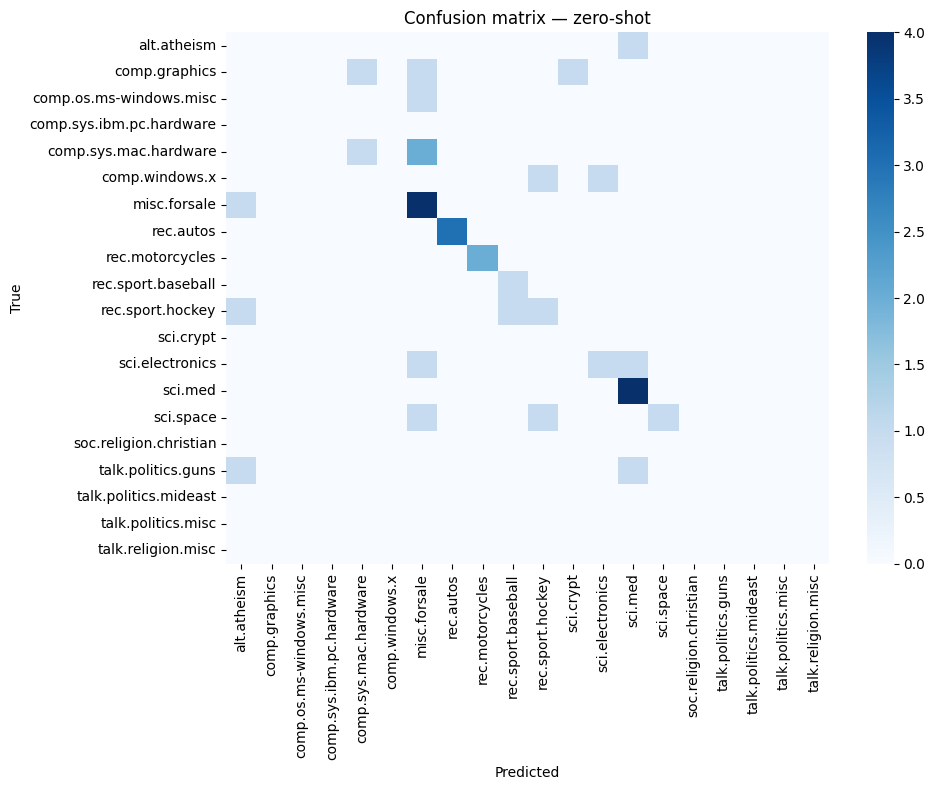

In [10]:
zero_shot_prompts = [build_zero_shot_prompt(t) for t in test_texts]
y_true            = [ID2LABEL[i] for i in test_labels]

pipe = make_pipeline()
y_pred_zs   = predict(zero_shot_prompts, pipe)
metrics_zs  = evaluate(y_true, y_pred_zs, name="zero-shot")
log_to_wandb(metrics_zs, name="zero-shot")

## 10 · Task 4b — Few-shot evaluation (k = 1, 3, 5)

For each `k`, demos are drawn from **`k` *different* classes** (one example
per class). Same seeded RNG → the demos for k=3 *extend* the demo for k=1,
and k=5 extends k=3. That makes the comparison clean: any improvement when
going from k=1 → k=3 is purely 'more demos', not 'different demos'.


>>> k=1 demos drawn from: ['comp.sys.ibm.pc.hardware']


predicting:   0%|          | 0/300 [00:00<?, ?it/s]


=== few-shot-k1 ===  acc=0.4833  macro-F1=0.4928  weighted-F1=0.4928
                          precision    recall  f1-score   support

             alt.atheism       0.24      0.60      0.35        15
           comp.graphics       0.33      0.47      0.39        15
 comp.os.ms-windows.misc       1.00      0.13      0.24        15
comp.sys.ibm.pc.hardware       0.36      0.53      0.43        15
   comp.sys.mac.hardware       0.78      0.47      0.58        15
          comp.windows.x       0.50      0.13      0.21        15
            misc.forsale       0.23      0.73      0.35        15
               rec.autos       0.86      0.80      0.83        15
         rec.motorcycles       0.83      0.33      0.48        15
      rec.sport.baseball       0.93      0.93      0.93        15
        rec.sport.hockey       1.00      0.73      0.85        15
               sci.crypt       0.59      0.67      0.62        15
         sci.electronics       0.88      0.47      0.61        15
     

accuracy,▁
f1_macro,▁
f1_weighted,▁
accuracy,0.48333
f1_macro,0.49279
f1_weighted,0.49279



>>> k=3 demos drawn from: ['comp.sys.ibm.pc.hardware', 'alt.atheism', 'rec.motorcycles']


...

accuracy,▁
f1_macro,▁
f1_weighted,▁
accuracy,0.44333
f1_macro,0.43871
f1_weighted,0.43871



>>> k=5 demos drawn from: ['comp.sys.ibm.pc.hardware', 'alt.atheism', 'rec.motorcycles', 'rec.autos', 'talk.politics.guns']


predicting:   0%|          | 0/300 [00:00<?, ?it/s]


=== few-shot-k5 ===  acc=0.4400  macro-F1=0.4194  weighted-F1=0.4194
                          precision    recall  f1-score   support

             alt.atheism       0.00      0.00      0.00        15
           comp.graphics       0.29      0.53      0.37        15
 comp.os.ms-windows.misc       0.50      0.13      0.21        15
comp.sys.ibm.pc.hardware       0.35      0.53      0.42        15
   comp.sys.mac.hardware       1.00      0.47      0.64        15
          comp.windows.x       0.31      0.27      0.29        15
            misc.forsale       0.23      0.60      0.33        15
               rec.autos       1.00      0.40      0.57        15
         rec.motorcycles       1.00      0.13      0.24        15
      rec.sport.baseball       0.81      0.87      0.84        15
        rec.sport.hockey       1.00      0.73      0.85        15
               sci.crypt       0.47      0.60      0.53        15
         sci.electronics       0.67      0.53      0.59        15
     

accuracy,▁
f1_macro,▁
f1_weighted,▁
accuracy,0.44
f1_macro,0.41944
f1_weighted,0.41944


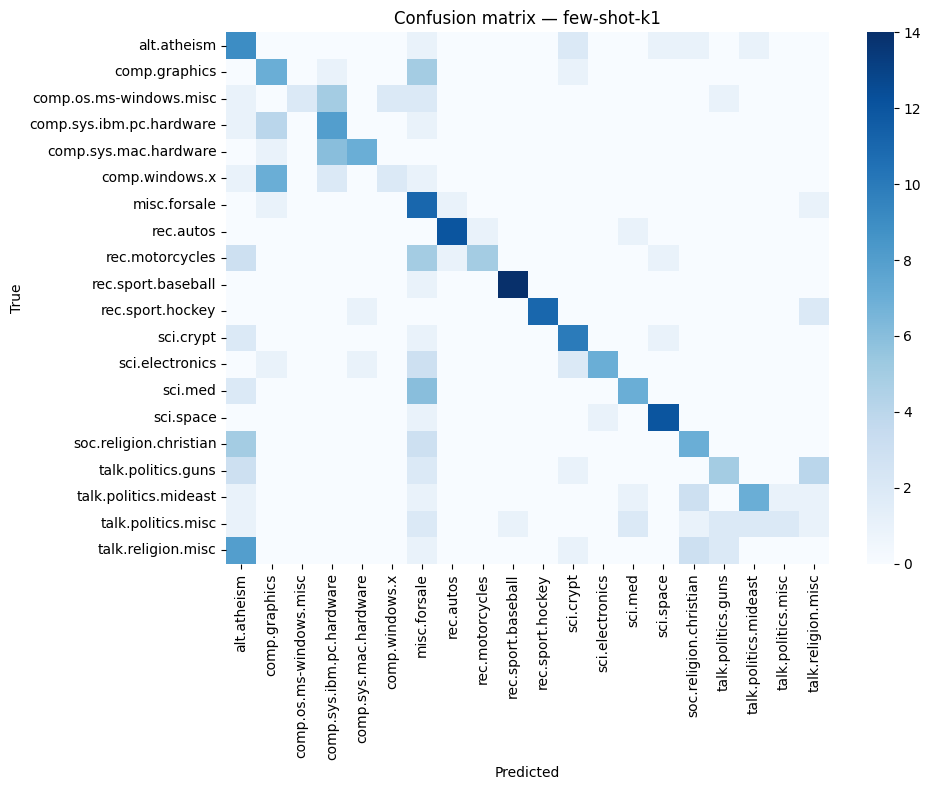

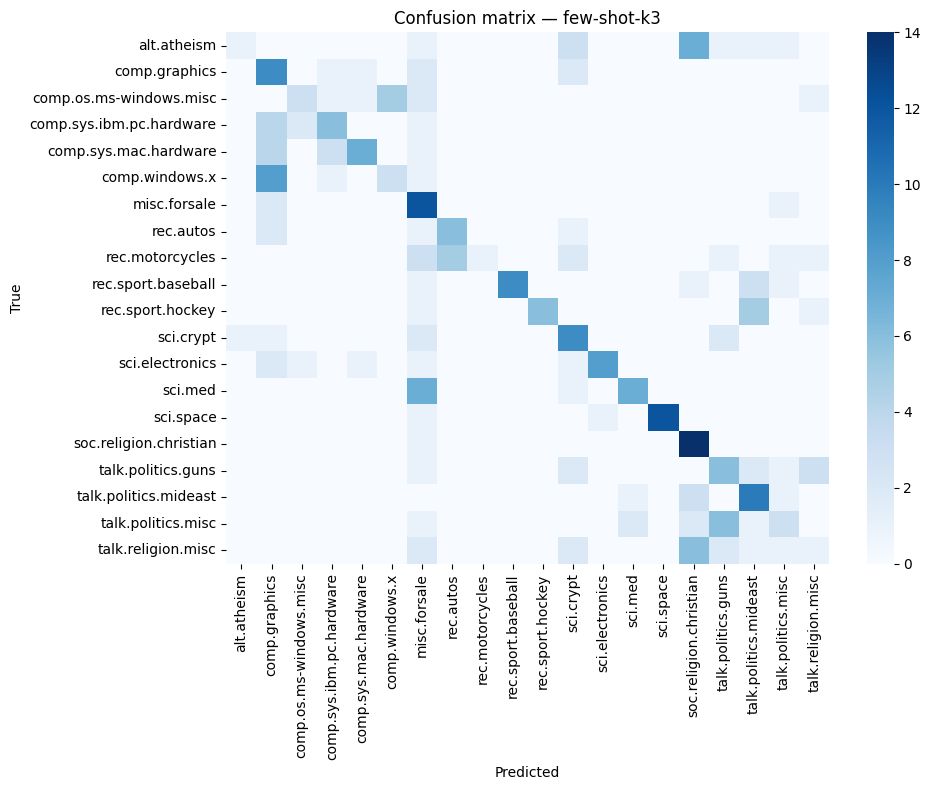

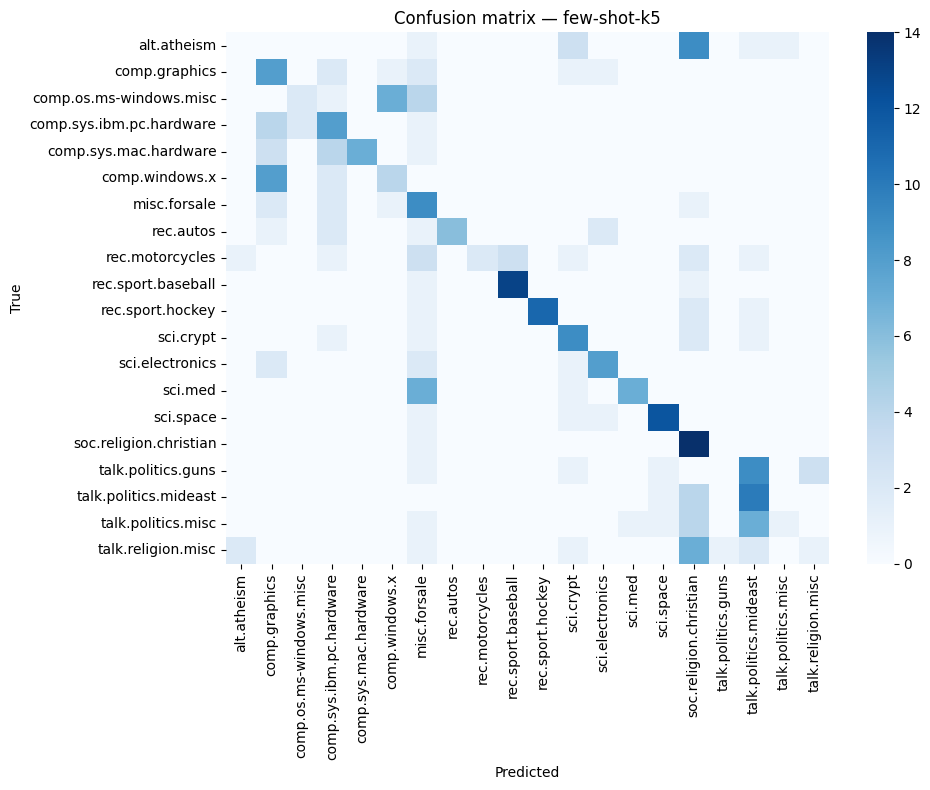

In [11]:
def sample_demos(k, rng):
    by_class = {i: [] for i in range(NUM_CLASSES)}
    for idx, lbl in enumerate(train_labels):
        by_class[int(lbl)].append(idx)
    chosen = rng.sample(range(NUM_CLASSES), k=min(k, NUM_CLASSES))
    return [(train_texts[rng.choice(by_class[c])], ID2LABEL[c])
            for c in chosen]

few_shot_results: Dict[int, Dict] = {}
for k in FEW_SHOT_KS:
    rng = random.Random(SEED)          # reset each k for reproducibility
    demos = sample_demos(k, rng)
    print(f"\n>>> k={k} demos drawn from:", [d[1] for d in demos])
    prompts_k = [build_few_shot_prompt(t, demos) for t in test_texts]
    y_pred_k  = predict(prompts_k, pipe)
    metrics_k = evaluate(y_true, y_pred_k, name=f"few-shot-k{k}")
    log_to_wandb(metrics_k, name=f"few-shot-k{k}", extra={"k": k})
    few_shot_results[k] = metrics_k

## 11 · Side-by-side confusion matrices

Plot zero-shot + the three few-shot regimes side by side. **This figure
goes straight into your report.**

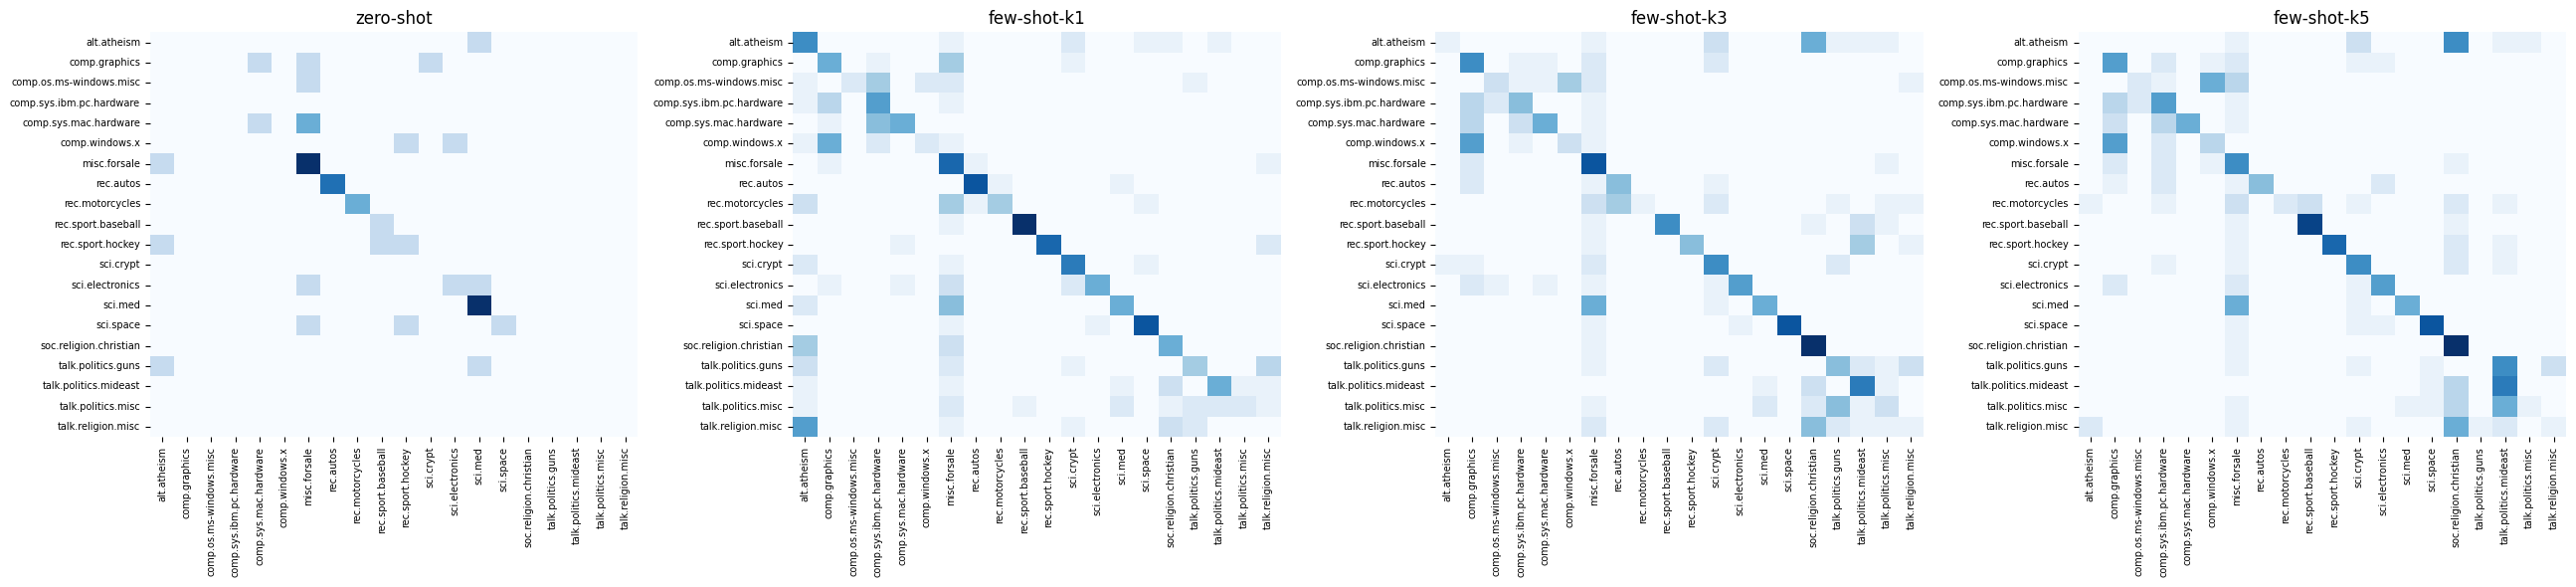

In [12]:
panels = [("zero-shot", metrics_zs["cm"])] + [
    (f"few-shot-k{k}", few_shot_results[k]["cm"]) for k in FEW_SHOT_KS
]
n = len(panels)
fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 6))
for ax, (name, cm) in zip(axes, panels):
    sns.heatmap(np.array(cm), xticklabels=LABELS, yticklabels=LABELS,
                cmap="Blues", annot=False, cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig("task4_confusion_matrices.png", dpi=120)
plt.show()

### 11.1 Accuracy and macro-F1 vs k

Plot the few-shot curve. Watch for: (a) does accuracy go up monotonically?
(b) does it plateau? (c) does it drop at k=5 — the long-prompt recency bias?

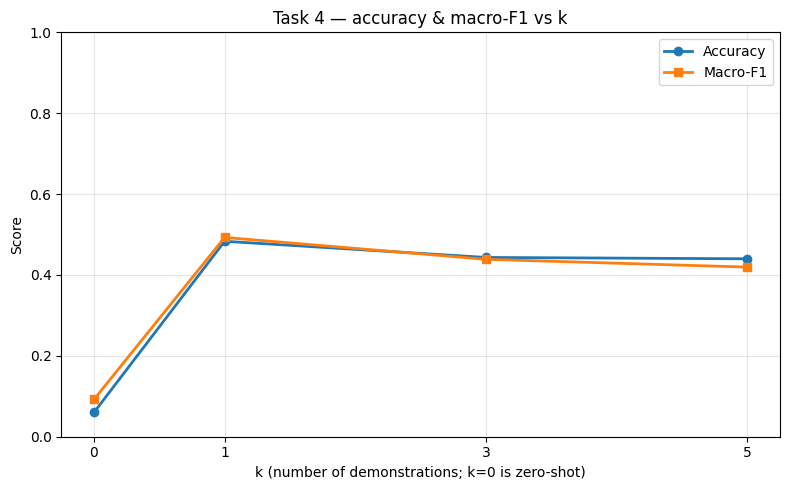

In [13]:
xs = [0] + FEW_SHOT_KS
accs = [metrics_zs["accuracy"]] + [few_shot_results[k]["accuracy"]   for k in FEW_SHOT_KS]
f1s  = [metrics_zs["f1_macro"]]  + [few_shot_results[k]["f1_macro"]   for k in FEW_SHOT_KS]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, accs, marker="o", linewidth=2, label="Accuracy")
ax.plot(xs, f1s,  marker="s", linewidth=2, label="Macro-F1")
ax.set_xticks(xs)
ax.set_xlabel("k (number of demonstrations; k=0 is zero-shot)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Task 4 — accuracy & macro-F1 vs k")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig("task4_acc_vs_k.png", dpi=120)
plt.show()

## 12 · Save metrics for the bonus notebook

Dump the four regimes' headline metrics to `task4_metrics.json`. The bonus
notebook reads this file to build the side-by-side comparison without
having to re-run zero-shot and few-shot evaluation.

In [14]:
import json

payload = {
    "zero-shot": {
        "accuracy":   metrics_zs["accuracy"],
        "f1_macro":   metrics_zs["f1_macro"],
        "f1_weighted":metrics_zs["f1_weighted"],
        "cm":         metrics_zs["cm"],
    },
    **{
        f"few-shot-k{k}": {
            "accuracy":    few_shot_results[k]["accuracy"],
            "f1_macro":    few_shot_results[k]["f1_macro"],
            "f1_weighted": few_shot_results[k]["f1_weighted"],
            "cm":          few_shot_results[k]["cm"],
        }
        for k in FEW_SHOT_KS
    },
    "labels": LABELS,
}
with open(METRICS_OUTPUT, "w") as f:
    json.dump(payload, f, indent=2)
print(f"Wrote {METRICS_OUTPUT}  ({METRICS_OUTPUT.stat().st_size / 1024:.1f} KB)")
print("\nIf you're running Task 4 + Bonus in separate Colab sessions,")
print("download this file now and upload it at the start of the Bonus notebook.")

Wrote task4_metrics.json  (19.5 KB)

If you're running Task 4 + Bonus in separate Colab sessions,
download this file now and upload it at the start of the Bonus notebook.


---

## 14 · Troubleshooting (skip unless something broke)

### Model load OOMs

Check `torch.cuda.mem_get_info()[0] / 1e9` — you need ≥ 6 GB free.
If less, **Runtime → Disconnect and delete runtime**, reconnect, run from
the top. A fresh T4 has the full 15.6 GB available.

### `403 Forbidden` on Llama-3 download

Your HF token doesn't have the gated-repo permission. Easiest fix: create a
fresh **Read** token (not fine-grained) at
`https://huggingface.co/settings/tokens`. Update the Colab secret. **Restart
the runtime** so the new token is picked up.

### Generation is very slow

Make sure `model.config.use_cache = True` (it should be — set in section 7).
Without the KV cache, generation is 5-10× slower.